In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)</font>
# 9절. 데이터 그룹화 및 집계

In [11]:
from statsmodels.api import datasets
iris=datasets.get_rdataset('iris').data
iris.iloc[::25]
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf. pivot_table

In [14]:
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].sum()

,Sepal.Length,Sepal.Width
Species,,
setosa,250.3,171.4
versicolor,296.8,138.5
virginica,329.4,148.7


In [ ]:
# 1) 그룹화 방법 1
#    df.groupby(by=[그룹핑 할 열이름])[집계함수 적용해서 출력 할 열들].기초통계함수()
# [함수적용해서 출력할 열들] 생략시 모든 열이 적용

In [15]:
iris.groupby('Species').describe()

Sepal.Length                                             Sepal.Width         ... Petal.Length      Petal.Width                                          
                  count   mean       std  min    25%  50%  75%  max       count   mean  ...          75%  max       count   mean       std  min  25%  50%  75%  max
Species                                                                                 ...                                                                        
setosa             50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8        50.0  3.428  ...        1.575  1.9        50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6
versicolor         50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0        50.0  2.770  ...        4.600  5.1        50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8
virginica          50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9        50.0  2.974  ...        5.875  6.9        50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5

[3 rows x 32 columns]

In [16]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [21]:
iris_grouped=iris.groupby('Species')
iris_grouped=iris.groupby(iris.Species)
iris_grouped_sum=iris_grouped.sum()
display(iris_grouped_sum)    #iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [22]:
#setosa와virginica 만 집계
iris_grouped_sum.loc[['setosa','virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [23]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [25]:
iris_grouped_sum.reset_index(inplace=True) #인덱스를 컬럼으로 편입시킴

In [26]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [31]:
iris_grouped_sum[(iris_grouped_sum.Species=='setosa')|(iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa','virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [33]:
# 1) 그룹화 방법 1-1 :그룹핑할 때 index를 컬럼 데이터로 편입(reset_index()가 필요 x)
#    df.groupby(by=[그룹핑 할 열이름], as_index=False)[집계함수 적용해서 출력 할 열들].기초통계함수()
# [함수적용해서 출력할 열들] 생략시 모든 열이 적용
iris.groupby('Species',as_index=False).sum()
iris.groupby(iris['Species'],as_index=False).sum()
iris.groupby(iris.Species,as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [37]:
#종별 Sepal.Length 와 Sepal.Width 의 평균
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [ ]:
#종별 sepal.length의 합계

In [40]:
iris.groupby('Species')[['Sepal.Length']].sum()

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [ ]:
iris.groupby('Species')['Sepal.Length',].sum()

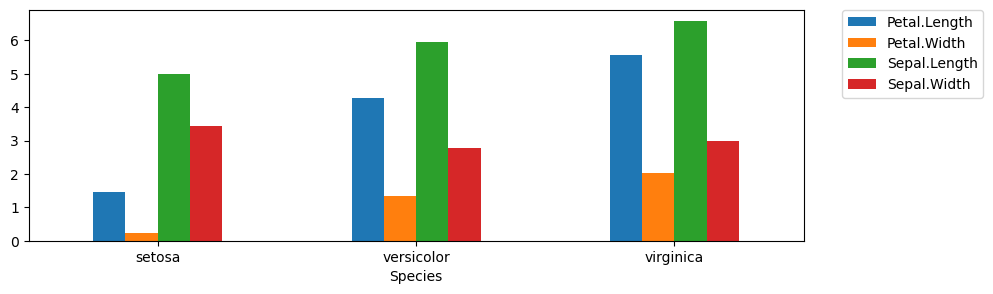

In [58]:
#그룹화방법1
#df.groupby(by=[그룹핑할열이름들], as_index=T/F)[함수적용해서출력할열들].함수명()
#그룹화방법2
#df.pivot_table(index='그룹핑할열이름또는이름들',
#               values='함수적용해서출력할열들', 
#               aggfunc=함수명(기본값:mean)
#               )
g= iris.pivot_table(index='Species',
                #values
                #aggfunc='sum'       
                )
import matplotlib.pyplot as plt
#범례를 밖으로 : 시각화20page. 판다스 60page.
g.plot(kind='bar',figsize=(10,3), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


In [46]:
iris.groupby('Species').mean()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [65]:
iris.pivot_table(index='Species', values='Sepal.Length', aggfunc='count')
iris.groupby('Species')[['Sepal.Length']].count()  #정렬이 안됨
iris['Species'].value_counts() #정렬까지

Species   
setosa        50
versicolor    50
virginica     50
dtype: int64

In [ ]:
#임의로 각 열마다 결측치를 할당(0번째열은 결측치1 / 1번째열은 결측치2 / 2번째열은 결측치3 / 3번째열은 결측치4)

In [80]:
import numpy as np
import random
random.sample(range(0,150),3)
for col in range(iris.shape[1]-1):
    rows=random.sample(range(len(iris)),col+1)
    iris.iloc[rows,col] = np.nan

In [82]:
iris.isna().sum()

Sepal.Length    2
Sepal.Width     4
Petal.Length    6
Petal.Width     8
Species         0
dtype: int64

In [83]:
#열별 결측치를 제외한 데이터 갯수
iris.count()

Sepal.Length    148
Sepal.Width     146
Petal.Length    144
Petal.Width     142
Species         150
dtype: int64

In [88]:
iris.groupby('Species').count()
iris.pivot_table(index='Species',aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,46,49,49
versicolor,48,46,50,49
virginica,47,50,49,48


In [89]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,NaN,setosa


In [96]:
#iris로 다중열 그룹화 하기위해 데이터 추가
#iris 행수는 150개 = Species 3그룹, num 6그룹
np.array([[i]*25 for i in range(6)]).flatten()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [101]:
iris['Num']=np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,Num
0,5.1,3.5,1.4,NaN,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,NaN,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [ ]:
#import pandas as pd
#pd.options.display.max_rows=150
#iris                                  전체열 다 확인하기 위함

In [107]:
#종별, num별 합계 
result=iris.groupby(['Species','Num']).sum()

In [109]:
result.index

MultiIndex([(    'setosa', 0),
            (    'setosa', 1),
            ('versicolor', 2),
            ('versicolor', 3),
            ( 'virginica', 4),
            ( 'virginica', 5)],
           names=['Species', 'Num'])

In [110]:
result.loc[['setosa','virginica']]

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   Num                                                      
setosa    0           125.7         87.0          35.0          5.3
          1           119.4         80.6          36.6          5.9
virginica 4           156.7         66.9         135.2         51.1
          5           165.0         75.5         126.6         50.2

In [111]:
result.loc[[('setosa',0),('virginica',5)]]

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,Num,,,,
setosa,0,125.7,87.0,35.0,5.3
virginica,5,165.0,75.5,126.6,50.2


In [112]:
#종별,num별 합계
iris.pivot_table(index=['Species','Num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    Num                                                      
setosa     0        1.458333     0.240909      5.028000     3.480000
           1        1.464000     0.245833      4.975000     3.358333
versicolor 2        4.326087     1.354167      6.012000     2.776000
           3        4.208000     1.318182      5.860000     2.737500
virginica  4        5.633333     2.044000      6.529167     2.908696
           5        5.504348     2.008000      6.600000     3.020000

In [114]:
#종별 기초 통계량들 다 출력
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  49.000000   50.000000  49.000000
             mean    5.002041    5.936000   6.565306
             std     0.355017    0.516171   0.621675
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.200000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   49.000000  48.000000
             mean    3.420408    2.757143   2.966667
             std     0.379133    0.303452   0.325729
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.500000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.600000    3.000000   3.125000
             max     4.400000    3.300000   3.800000
Petal.Length count  49.000000   48.000000  47.000000
             mean    1.461224    4.264583   5.570213
             std     0.175376    0.465622   0.555962
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.600000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  46.000000   46.000000  50.000000
             mean    0.243478    1.336957   2.026000
             std     0.106775    0.197043   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
Num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000